# Customer Churn Analysis using Machine Learning

This notebook performs a comprehensive customer churn analysis on the Telco Customer Churn dataset. We will explore the key drivers behind customer churn and build a Random Forest Classifier to predict whether a customer is likely to leave. The finalized model is saved for integration into a web-based dashboard.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import joblib

# Set plotting aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 1. Load and Inspect the Dataset

We begin by loading the Telco Customer Churn dataset from the `data` directory.

In [2]:
df = pd.read_csv('data/Telco-Customer-Churn.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning & Preprocessing

- Convert `TotalCharges` to numeric, converting empty strings to NaN.
- Fill missing `TotalCharges` values with 0.0, representing new customers with 0 tenure.
- Map the target variable `Churn` to binary values (0 for 'No', 1 for 'Yes').

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
print(f'Missing values in TotalCharges after conversion: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.info()

Missing values in TotalCharges after conversion: 11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Exploratory Data Analysis (EDA)

We visualize customer characteristics and their relationship with churn.

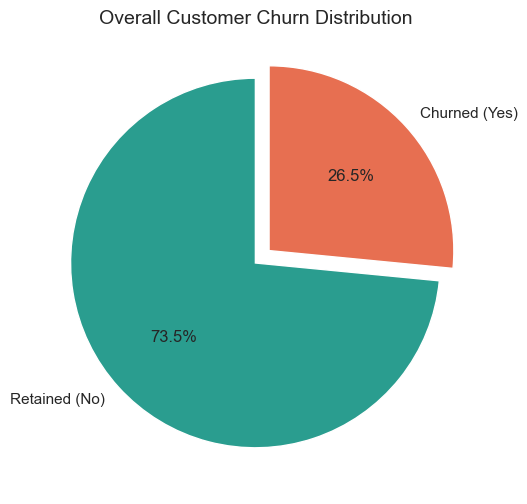

In [4]:
# Customer Churn Distribution
churn_counts = df['Churn'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['Retained (No)', 'Churned (Yes)'], autopct='%1.1f%%', 
        colors=['#2A9D8F', '#E76F51'], startangle=90, explode=(0, 0.1))
plt.title('Overall Customer Churn Distribution')
plt.show()

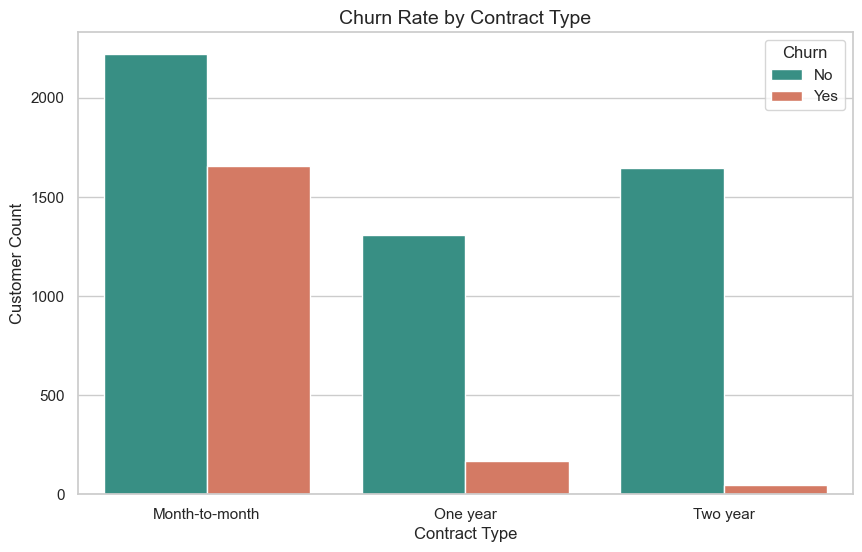

In [5]:
# Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue=df['Churn'].map({0: 'No', 1: 'Yes'}), 
              palette=['#2A9D8F', '#E76F51'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Customer Count')
plt.xlabel('Contract Type')
plt.show()

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25428\2478499357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['Churn'].map({0: 'No', 1: 'Yes'}), y='tenure',


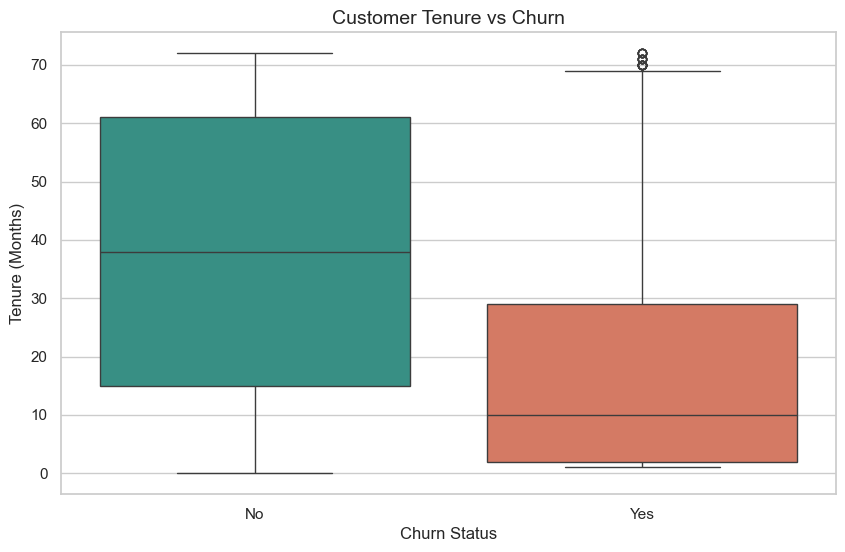

In [6]:
# Tenure vs Churn Box Plot
sns.boxplot(data=df, x=df['Churn'].map({0: 'No', 1: 'Yes'}), y='tenure', 
            palette=['#2A9D8F', '#E76F51'])
plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25428\2455931914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['Churn'].map({0: 'No', 1: 'Yes'}), y='MonthlyCharges',


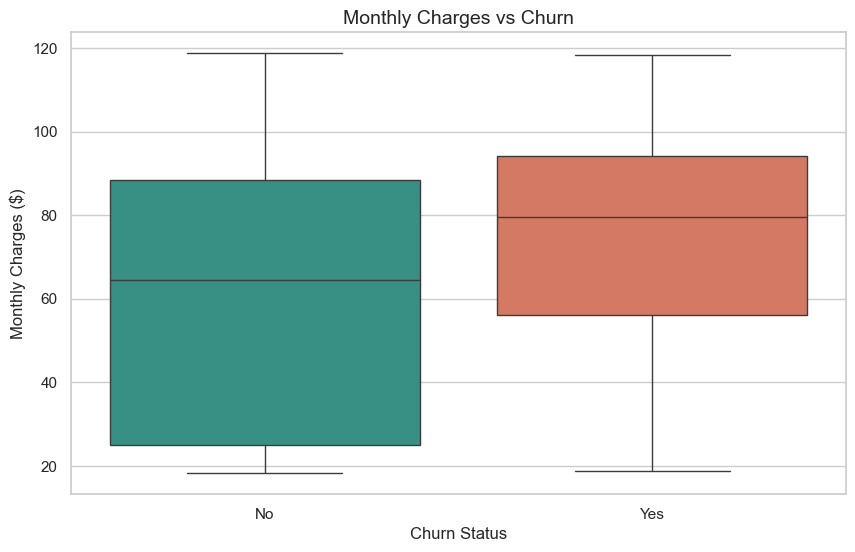

In [7]:
# Monthly Charges vs Churn Box Plot
sns.boxplot(data=df, x=df['Churn'].map({0: 'No', 1: 'Yes'}), y='MonthlyCharges', 
            palette=['#2A9D8F', '#E76F51'])
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

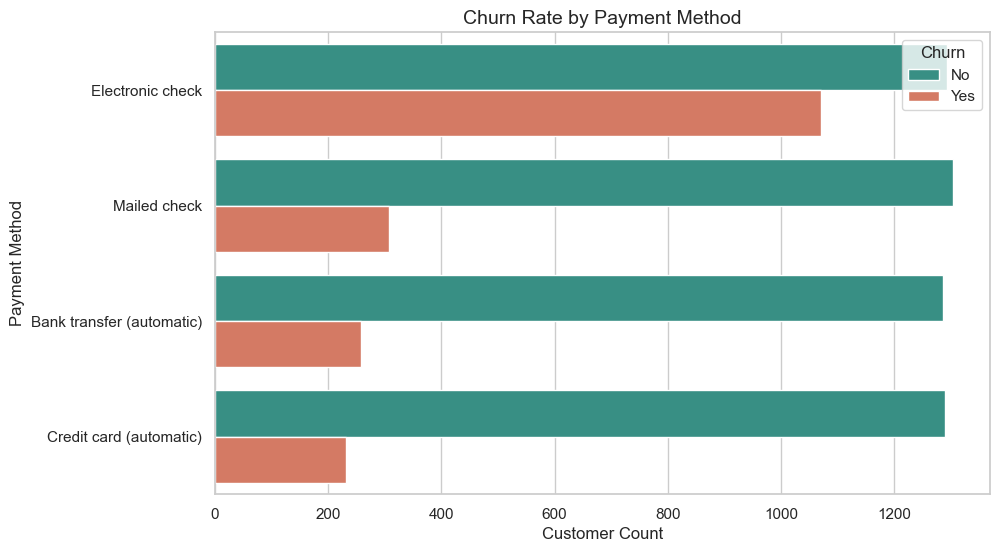

In [8]:
# Payment Method vs Churn
sns.countplot(data=df, y='PaymentMethod', hue=df['Churn'].map({0: 'No', 1: 'Yes'}), 
              palette=['#2A9D8F', '#E76F51'])
plt.title('Churn Rate by Payment Method')
plt.xlabel('Customer Count')
plt.ylabel('Payment Method')
plt.show()

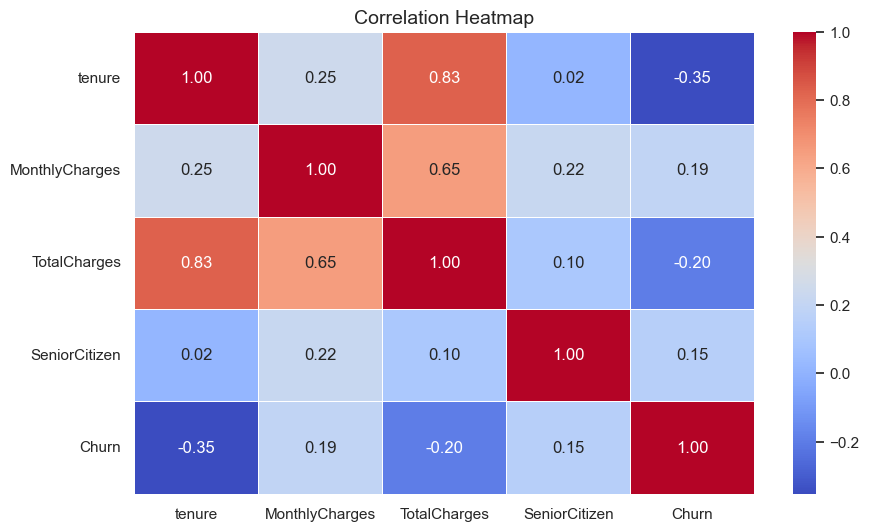

In [9]:
# Correlation Heatmap for Numerical Features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 4. Model Training & Pipeline Construction

We build a pipeline to preprocess the features and train a Random Forest Classifier. The model is restricted to the 11 variables that will be collected in the user form.

In [10]:
features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'tenure', 'PhoneService', 'InternetService', 
    'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]
X = df[features]
y = df['Churn']

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

clf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=4, class_weight='balanced', random_state=42)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', clf)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_pipeline.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


## 5. Model Evaluation

We evaluate the model on the test set.

Accuracy Score: 0.7580

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

Confusion Matrix:


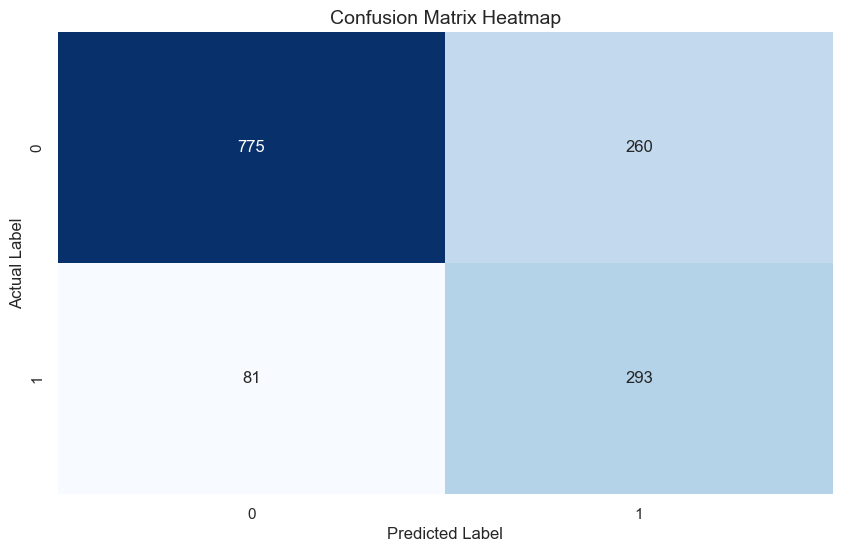

In [11]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(f'Accuracy Score: {model_pipeline.score(X_test, y_test):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

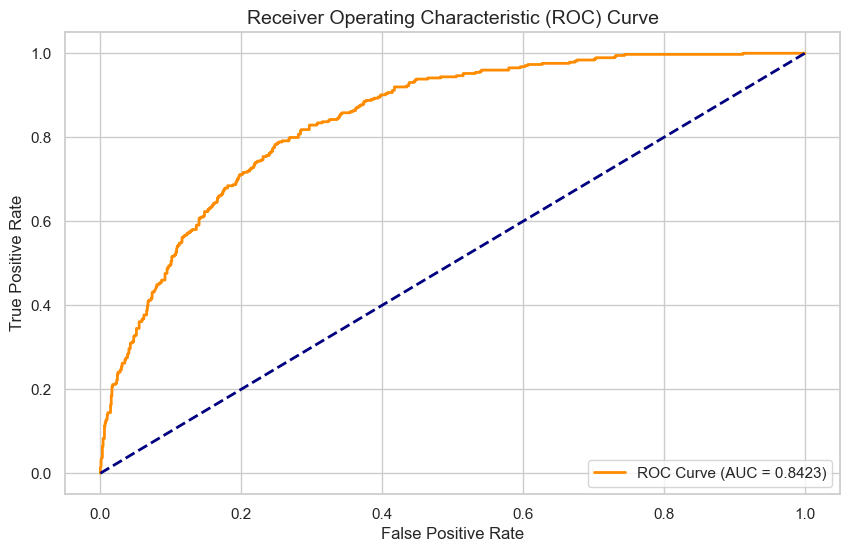

In [12]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 6. Feature Importance

We compute feature importances and aggregate them back to their original feature groups.

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25428\3578622301.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_imp_df.head(10), x='importance', y='feature', palette='viridis')


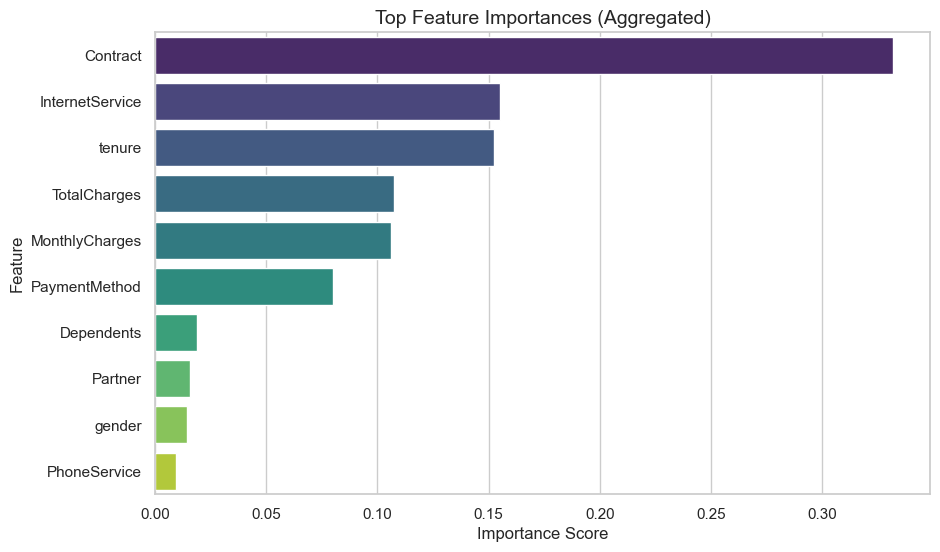

In [13]:
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cats = list(cat_encoder.get_feature_names_out(categorical_cols))
all_features = encoded_cats + numerical_cols
importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances})

# Aggregate importances
agg_importances = {}
for col in features:
    if col in categorical_cols:
        agg_importances[col] = feature_imp_df[feature_imp_df['feature'].str.startswith(col)]['importance'].sum()
    else:
        agg_importances[col] = feature_imp_df[feature_imp_df['feature'] == col]['importance'].values[0]

agg_imp_df = pd.DataFrame(list(agg_importances.items()), columns=['feature', 'importance']).sort_values(by='importance', ascending=False)

# Plot
sns.barplot(data=agg_imp_df.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top Feature Importances (Aggregated)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 7. Save Model Pipeline

Save the fully trained pipeline using `joblib` so it can be deployed directly in the Streamlit application.

In [14]:
joblib.dump(model_pipeline, 'trained_model.pkl')
print('Model pipeline successfully exported!')

Model pipeline successfully exported!
